# Notebook 03 — Baseline Models

In [1]:
# Switch to GPU if present
import torch

print(torch.backends.mps.is_available())
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

x = torch.randn(5, 5).to(device)
print(x.device)

True
mps:0


In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pickle
import time
import numpy as np
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from src.config import RESULTS_DIR
from src.evaluation import (
    compute_metrics, save_results,
    plot_confusion_matrix, plot_roc_curve,
    print_classification_report,
)

## Load Preprocessed Data

In [3]:
with open(os.path.join(RESULTS_DIR, 'preprocessed_data.pkl'), 'rb') as f:
    data = pickle.load(f)

train_df = data['train_df']
val_df   = data['val_df']
test_df  = data['test_df']
X_train  = data['tfidf_data']['X_train']
X_val    = data['tfidf_data']['X_val']
X_test   = data['tfidf_data']['X_test']

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')

Train: (140000, 50000), Val: (20000, 50000), Test: (40000, 50000)



## Model 1 — Majority Class Baseline

=== Majority Class Baseline ===
              precision    recall  f1-score   support

 Non-Spoiler       0.74      1.00      0.85     29481
     Spoiler       0.00      0.00      0.00     10519

    accuracy                           0.74     40000
   macro avg       0.37      0.50      0.42     40000
weighted avg       0.54      0.74      0.63     40000

Confusion matrix saved → /Users/hardikk/Desktop/spoiler-detection-nlp/results/model_charts/majority_class_cm.png


/Users/hardikk/Desktop/spoiler-detection-nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hardikk/Desktop/spoiler-detection-nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/hardikk/Desktop/spoiler-detection-nlp/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

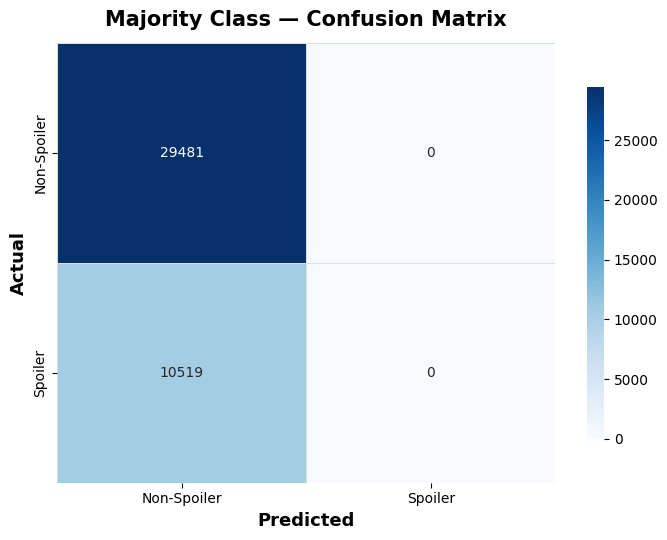

Results saved → /Users/hardikk/Desktop/spoiler-detection-nlp/results/model_results/majority_class.json


'/Users/hardikk/Desktop/spoiler-detection-nlp/results/model_results/majority_class.json'

In [4]:
majority = DummyClassifier(strategy='most_frequent')
majority.fit(X_train, y_train)

y_pred = majority.predict(X_test)

metrics = compute_metrics(y_test, y_pred)
print('=== Majority Class Baseline ===')
print_classification_report(y_test, y_pred)

plot_confusion_matrix(y_test, y_pred,
                      title='Majority Class — Confusion Matrix',
                      save_name='majority_class')

save_results('majority_class', metrics,
             extra={'strategy': 'most_frequent',
                    'description': 'Always predicts the majority class (non-spoiler)'})

## Model 2 — Multinomial Naive Bayes

Val F1: 0.2545

=== Multinomial Naive Bayes (test) ===
              precision    recall  f1-score   support

 Non-Spoiler       0.77      0.97      0.86     29481
     Spoiler       0.67      0.17      0.27     10519

    accuracy                           0.76     40000
   macro avg       0.72      0.57      0.56     40000
weighted avg       0.74      0.76      0.70     40000

Confusion matrix saved → /Users/hardikk/Desktop/spoiler-detection-nlp/results/model_charts/naive_bayes_cm.png


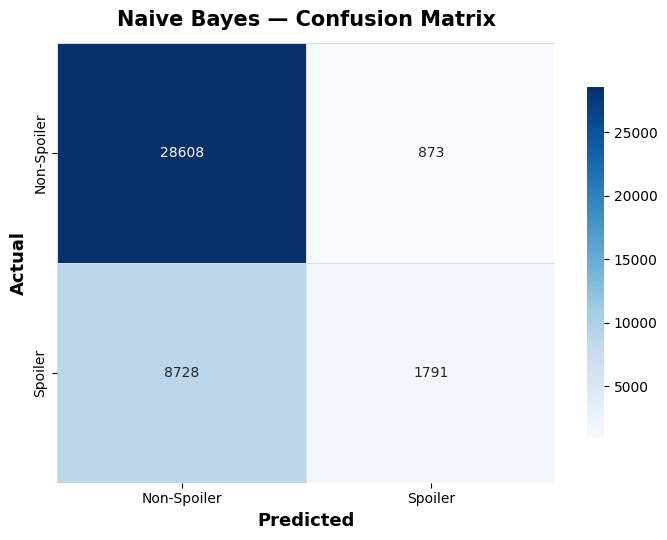

ROC curve saved → /Users/hardikk/Desktop/spoiler-detection-nlp/results/model_charts/naive_bayes_roc.png


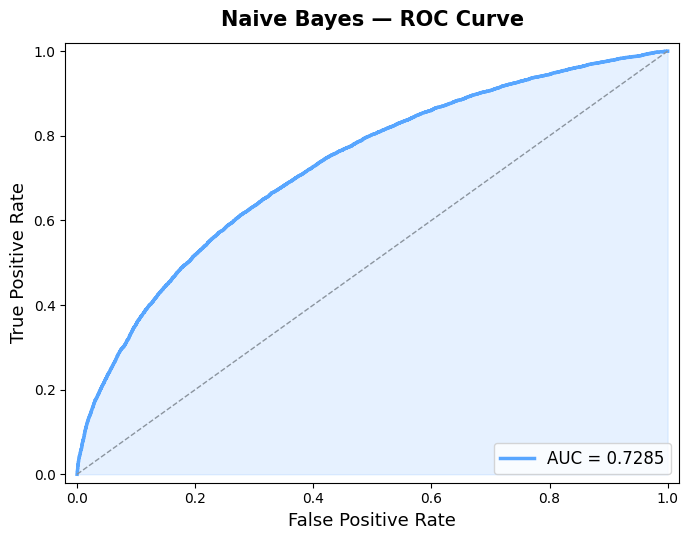

Results saved → /Users/hardikk/Desktop/spoiler-detection-nlp/results/model_results/naive_bayes.json


'/Users/hardikk/Desktop/spoiler-detection-nlp/results/model_results/naive_bayes.json'

In [5]:
t = time.time()

nb = MultinomialNB(alpha=1.0)
nb.fit(X_train, y_train)

train_time = time.time() - t

# Validation performance (for reference)
y_val_pred = nb.predict(X_val)
val_metrics = compute_metrics(y_val, y_val_pred)
print(f'Val F1: {val_metrics["f1"]:.4f}')

# Test performance
y_pred = nb.predict(X_test)
y_prob = nb.predict_proba(X_test)[:, 1]

metrics = compute_metrics(y_test, y_pred, y_prob)

print(f'\n=== Multinomial Naive Bayes (test) ===')
print_classification_report(y_test, y_pred)

plot_confusion_matrix(y_test, y_pred,
                      title='Naive Bayes — Confusion Matrix',
                      save_name='naive_bayes')

plot_roc_curve(y_test, y_prob,
               title='Naive Bayes — ROC Curve',
               save_name='naive_bayes')

save_results('naive_bayes', metrics,
             extra={'alpha': 1.0,
                    'training_time_seconds': round(train_time, 2),
                    'val_f1': val_metrics['f1']})

## Model 3 — Logistic Regression

/Users/hardikk/Desktop/spoiler-detection-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/hardikk/Desktop/spoiler-detection-nlp/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Val F1: 0.5395

=== Logistic Regression (test) ===
              precision    recall  f1-score   support

 Non-Spoiler       0.85      0.76      0.80     29481
     Spoiler       0.48      0.63      0.54     10519

    accuracy                           0.72     40000
   macro avg       0.66      0.69      0.67     40000
weighted avg       0.75      0.72      0.73     40000

Confusion matrix saved → /Users/hardikk/Desktop/spoiler-detection-nlp/results/model_charts/logistic_regression_cm.png


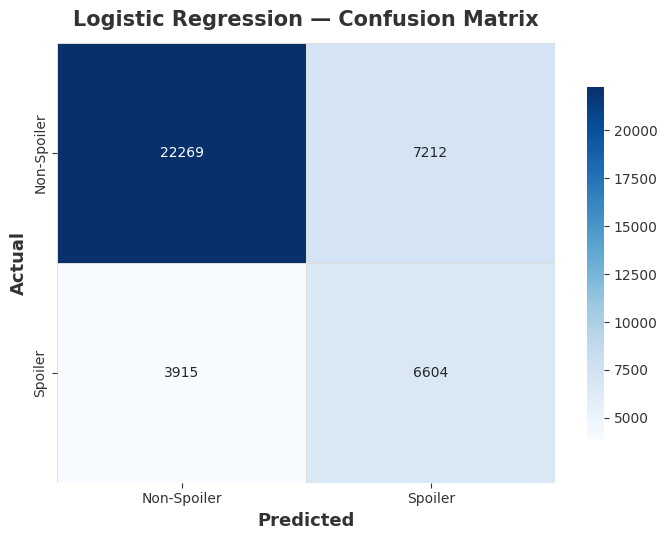

ROC curve saved → /Users/hardikk/Desktop/spoiler-detection-nlp/results/model_charts/logistic_regression_roc.png


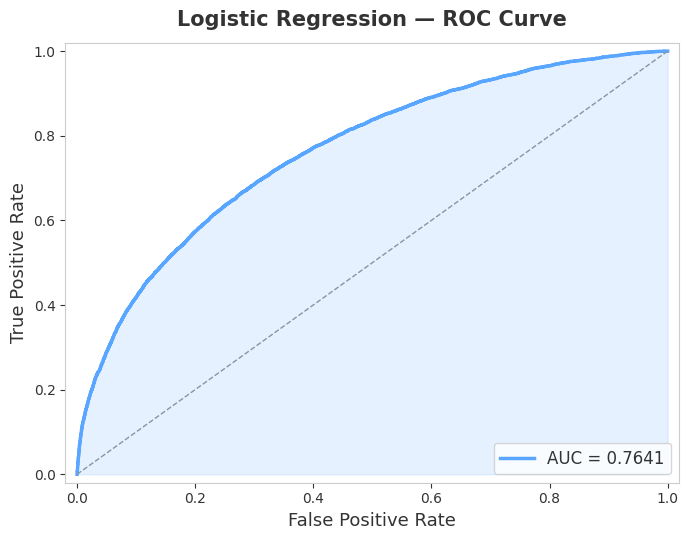

Results saved → /Users/hardikk/Desktop/spoiler-detection-nlp/results/model_results/logistic_regression.json


'/Users/hardikk/Desktop/spoiler-detection-nlp/results/model_results/logistic_regression.json'

In [ ]:
t0 = time.time()

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='saga',
    penalty='l2',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
lr.fit(X_train, y_train)

train_time_lr = time.time() - t0

# Validation
y_val_pred_lr = lr.predict(X_val)
val_metrics_lr = compute_metrics(y_val, y_val_pred_lr)
print(f'Val F1: {val_metrics_lr["f1"]:.4f}')

# Test
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

metrics_lr = compute_metrics(y_test, y_pred_lr, y_prob_lr)
print(f'\n=== Logistic Regression (test) ===')
print_classification_report(y_test, y_pred_lr)

plot_confusion_matrix(y_test, y_pred_lr,
                      title='Logistic Regression — Confusion Matrix',
                      save_name='logistic_regression')

plot_roc_curve(y_test, y_prob_lr,
               title='Logistic Regression — ROC Curve',
               save_name='logistic_regression')

save_results('logistic_regression', metrics_lr,
             extra={'C': 1.0, 'solver': 'saga',
                    'class_weight': 'balanced',
                    'training_time_seconds': round(train_time_lr, 2),
                    'val_f1': val_metrics_lr['f1']})

## Feature Importance — Top Spoiler Indicators

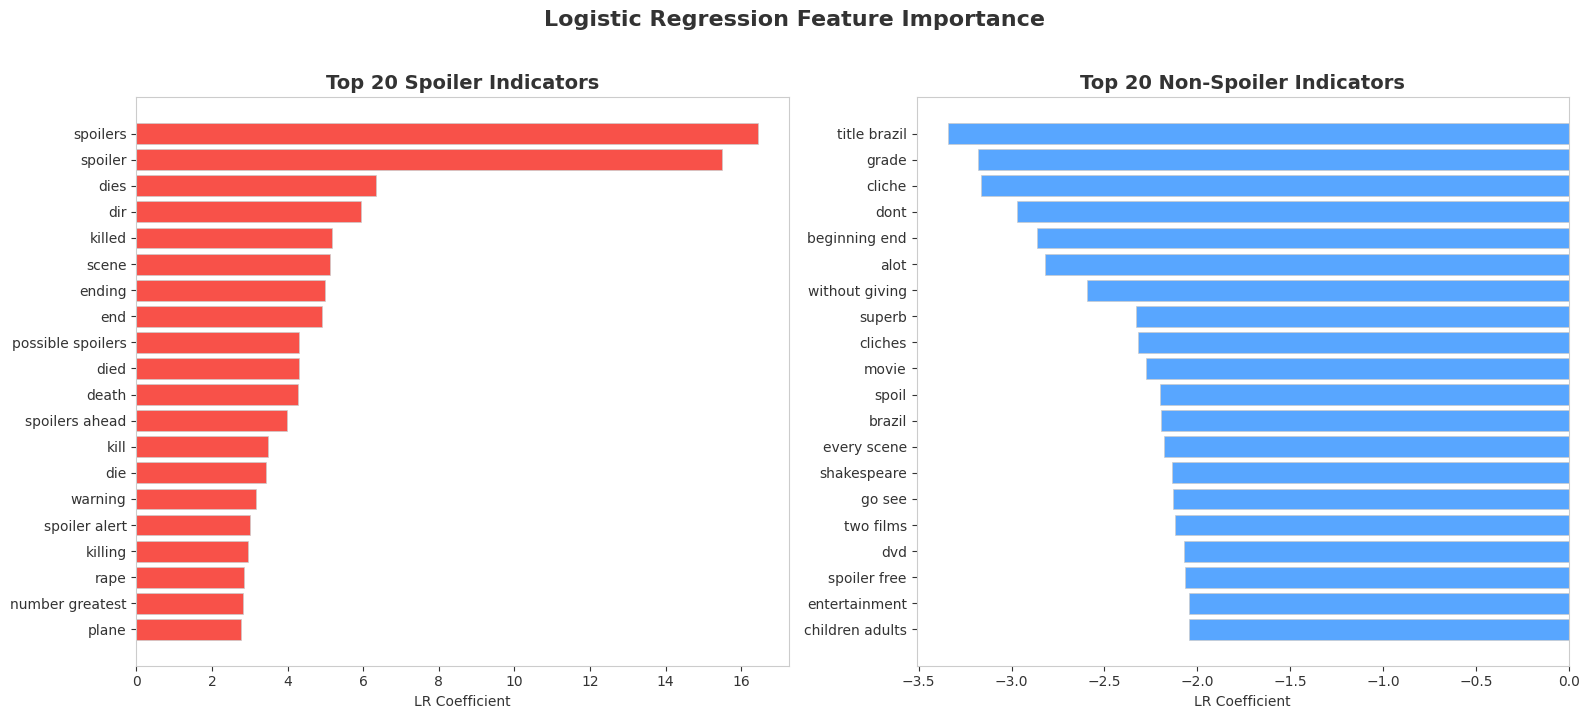

In [16]:
import matplotlib.pyplot as plt

# Light theme
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'axes.labelcolor': '#333333',
    'text.color': '#333333',
    'xtick.color': '#333333',
    'ytick.color': '#333333',
})

feature_names = data['tfidf_data']['vectorizer'].get_feature_names_out()
coefs = lr.coef_[0]

# Top 20 features for spoiler (positive class)
top_spoiler_idx = coefs.argsort()[::-1][:20]
top_clean_idx   = coefs.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Spoiler indicators
names_sp = [feature_names[i] for i in top_spoiler_idx][::-1]
vals_sp  = [coefs[i] for i in top_spoiler_idx][::-1]
axes[0].barh(names_sp, vals_sp, color='#f85149', edgecolor='#cccccc', linewidth=0.5)
axes[0].set_title('Top 20 Spoiler Indicators', fontsize=14, fontweight='bold')
axes[0].set_xlabel('LR Coefficient')

# Non-spoiler indicators
names_cl = [feature_names[i] for i in top_clean_idx][::-1]
vals_cl  = [coefs[i] for i in top_clean_idx][::-1]
axes[1].barh(names_cl, vals_cl, color='#58a6ff', edgecolor='#cccccc', linewidth=0.5)
axes[1].set_title('Top 20 Non-Spoiler Indicators', fontsize=14, fontweight='bold')
axes[1].set_xlabel('LR Coefficient')

plt.suptitle('Logistic Regression Feature Importance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/model_charts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Baseline Summary

Spoiler, Non-Spoiler --> 74%, 0%
| Model | Accuracy | Precision | Recall | F1 |
|---|---|---|---|---|
| Majority Class | 74% | 74%, 0% | 100%, 0% | 85%, 0% |
| Naive Bayes | 76% | 77%, 67% | 97%, 17% | 86%, 27% |
| Logistic Regression | 72% | 85%, 48% | 75%, 63% | 80%, 54% |

*(Actual values will fill in when you run the notebook.)*

Results saved as JSON:
- `results/majority_class.json`
- `results/naive_bayes.json`
- `results/logistic_regression.json`